In [ ]:
import numpy as np
import xarray as xr
import sys
sys.path.append('../')
from xdispersion import RelativeDispersion
import matplotlib.cm as cm
from matplotlib import cm
import matplotlib.pyplot as plt
import pandas as pd

save=False  #save figures or not
namedata = "ExpO" #ExpA or ExpAnomean
drifters = xr.open_dataset('./data/ExpO/fort.2001nomean.np4000nt6000.nc')
npa = drifters.dims['tracer'] #number particles

#rd = RelativeDispersion(drifters, ragged=False, ID='tracer',
#                        xpos='x', uvel='ux', time='time',
#                        ypos='y', vvel='uy', coord='cartesian')
rd = RelativeDispersion(drifters, ragged=False, ID='tracer',
                        xpos='x', uvel='ux', time='time',
                        ypos='y', vvel='uy', coord='polar')

pairs = rd.get_all_pairs()
origin_pairs = rd.get_original_pairs(pairs, r0=[0.005, 0.01])



/tmp/ipykernel_165977/3408269786.py:14: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  npa = drifters.dims['tracer'] #number particles


In [194]:
from xdispersion import gen_rbins, rel_disp, rel_diff, kurtosis, cumul_inv_sep_time, famp_growth_rate, fsize_lyap_exp

alpha = 1.2
rbins = gen_rbins(0.01, 0.5, alpha)

# get all building blocks for the four measures. Here, rx is radial dispersion, ry means nothing and r is total dispersion
rx, ry, rxy, r, rpb = rd.separation_measures(origin_pairs)

r2   = rel_disp(r, order=2, mean_at='const-t') #order=2 so 2nd moment of separation
K2   = rel_diff(r, mean_at='const-t') #Relative diffusivity
Ku   = kurtosis(r, mean_at='const-t') #kurtosis=4th moment


### Fit beta

In [195]:
import numpy as np

# --- Choose the fitting range ---
rtmp = np.sqrt(r2)
rmin, rmax = 1e-2, 1.3e-1 
mask = (rtmp >= rmin) & (rtmp <= rmax)
x = np.log10(rtmp[mask])
y = np.log10(K2[mask])

# --- Fixed slope ---
fixed_slope = 4/3

# --- Fit intercept analytically ---
# Model: y = intercept + fixed_slope * x
intercept = float(np.mean(y - fixed_slope * x))

# --- Residuals and standard error on intercept ---
residuals = y - (intercept + fixed_slope * x)
n = len(y)
intercept_stderr = float(np.std(residuals, ddof=1)) # / np.sqrt(n))

# --- Convert intercept to physical coefficient ---
C = 10**intercept
C_err = C * np.log(10) * intercept_stderr  # propagate error to linear space

print(intercept)
print(intercept_stderr)
print(f"beta {10**(intercept)/2.61:.1e}")
print(f"betamin {10**(intercept-intercept_stderr)/2.61:.1e}")
print(f"betamax {10**(intercept+intercept_stderr)/2.61:.1e}")

#plt.plot(x,y - (intercept + fixed_slope * x))

-2.8627175441977597
0.16649592519923279
beta 5.3e-04
betamin 3.6e-04
betamax 7.7e-04


### Fit kappa

In [196]:
import numpy as np

# --- Choose the fitting range ---
rmin2, rmax2 = 1e-1, 3e-1 
mask = (rtmp >= rmin2) & (rtmp <= rmax2)
x = np.log10(rtmp[mask])
y = np.log10(K2[mask])
intercept2 = float(np.mean(y))
# --- Residuals and standard error on intercept ---
residuals = y - (intercept2)
intercept_stderr2 = float(np.std(residuals, ddof=1)) # / np.sqrt(n))

# --- Convert intercept to physical coefficient ---
D = 10**intercept2
D_err = D * np.log(10) * intercept_stderr2  # propagate error to linear space

print(intercept2)
print(intercept_stderr2)
print(f"kappa {10**(intercept2)/2:.1e}")
print(f"kappamin {10**(intercept2-intercept_stderr2)/2:.1e}")
print(f"kappamax {10**(intercept2+intercept_stderr2)/2:.1e}")

#plt.plot(x,y - (intercept + fixed_slope * x))

-4.365021303368734
0.10456092286854858
kappa 2.2e-05
kappamin 1.7e-05
kappamax 2.7e-05


### Fit T

In [197]:
import numpy as np

# --- Choose the fitting range ---
tmin, tmax = 0, 14
mask = (Ku.rtime >= tmin) & (Ku.rtime <= tmax)
x = 8*Ku.rtime[mask]
y = np.log(Ku[mask])

slope = np.sum(x * y) / np.sum(x**2)
# --- Compute residuals and standard error ---
y_pred = slope * x
residuals = y - y_pred
n = len(x)
# Standard error of the slope (no intercept fit)
s_var = np.sum(residuals**2) / (n - 1)
slope_stderr = np.sqrt(s_var / np.sum(x**2))

# --- Bootstrap to estimate slope uncertainty ---
n_boot = 10000
slopes_boot = np.zeros(n_boot)

for i in range(n_boot):
    indices = np.random.randint(0, n, n)  # sample with replacement
    x_sample = x[indices]
    y_sample = y[indices]
    slopes_boot[i] = np.sum(x_sample * y_sample) / np.sum(x_sample**2)

# --- Compute 95% confidence interval from bootstrap ---
slope_lower = np.percentile(slopes_boot, 2.5)
slope_upper = np.percentile(slopes_boot, 97.5)
slope_median = np.median(slopes_boot)

print(f"Original slope = {slope:.4f}")
print(f"Bootstrap slope median = {slope_median:.4f}")
print(f"Bootstrap 95% CI = [{slope_lower:.4f}, {slope_upper:.4f}]")



Original slope = 0.0095
Bootstrap slope median = 0.0095
Bootstrap 95% CI = [0.0094, 0.0095]


105.73337824515667
106.43077736293978
105.1342190464092


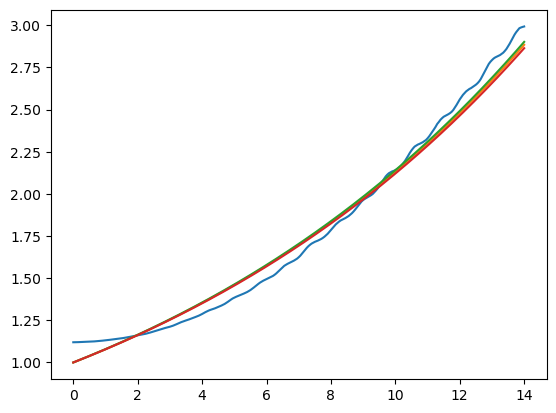

In [198]:

print(1/slope_median)
print(1/(slope_lower))
print(1/(slope_upper))

#print(1/slope.values)
#print(1/(slope.values-slope_stderr.values))
#print(1/(slope.values+slope_stderr.values))

plt.plot(x/8,np.exp(y))
plt.plot(x/8,np.exp(x*slope.values))
plt.plot(x/8,np.exp(x*slope_upper))
plt.plot(x/8,np.exp(x*slope_lower))



(0.0, 50.0)

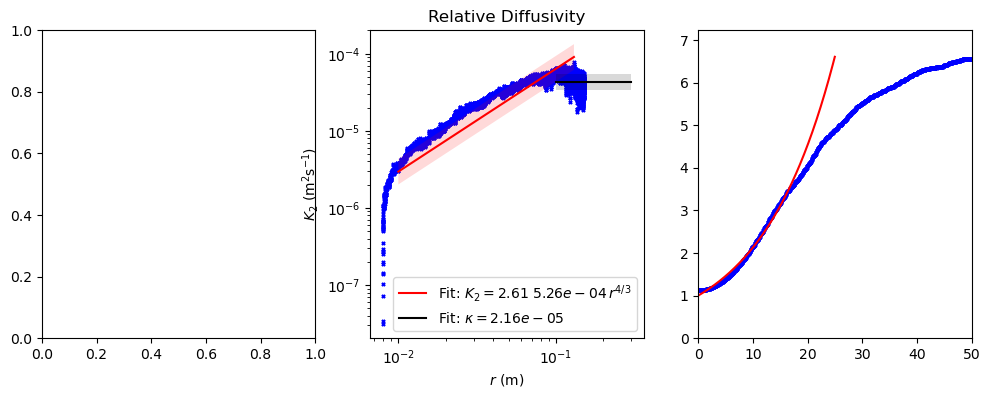

In [200]:

# --- Construct fit line ---
fit_r = np.linspace(rmin, rmax, 100)
fit_r2 = np.linspace(rmin2, rmax2, 100)
fit_K2 = C*fit_r**(4/3) #10**(intercept + fixed_slope * np.log10(fit_r))
fit_K2_upper = 10**((intercept + intercept_stderr) + fixed_slope * np.log10(fit_r))
fit_K2_lower = 10**((intercept - intercept_stderr) + fixed_slope * np.log10(fit_r))


# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # (rows, cols)
axes[1].scatter(rtmp.values, K2.values, marker='x', s=5, color='b')
#axes[1].fill_between(rtmp, 2.61*betamin*rtmp**(4/3), 2.61*betamax*rtmp**(4/3),
#                     color='r', alpha=0.15, edgecolor=None)
#axes[1].fill_between(rtmp, rtmp*0+2*kappalmin, rtmp*0+2*kappalmax,
#                     color='k', alpha=0.1, edgecolor=None)
#axes[1].plot(rtmp, 2.61*beta*rtmp**(4/3), color='r',
#             label=r'$2.61 \epsilon^{1/3} r^{4/3}$', linewidth=1.0)
#axes[1].plot(rtmp, rtmp*0+2*kappal, 'k',
#             label=fr'$2\kappa$ ($\kappa$ = {kappal:.1e} m$^2$s$^{{-1}}$)', linewidth=1.0)

# Add the constrained fit
axes[1].plot(fit_r, fit_K2, 'r-',
             label=fr'Fit: $K_2 = 2.61~ {C/2.61:.2e}\,r^{{4/3}}$')
axes[1].fill_between(fit_r, fit_K2_lower, fit_K2_upper,
                     color='r', alpha=0.15, edgecolor=None)
axes[1].plot(fit_r2, fit_r2*0+D, 'k-',
             label=fr'Fit: $\kappa = {D/2:.2e}$')
axes[1].fill_between(fit_r2, fit_r2*0+10**(intercept2-intercept_stderr2), 
                     10**(intercept2+intercept_stderr2),
                     color='k', alpha=0.15, edgecolor=None)
axes[1].set_title("Relative Diffusivity")
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel(r"$r$ (m)")
axes[1].set_ylabel(r"$K_2$ (m$^2$s$^{{-1}}$)")
axes[1].legend()

axes[2].scatter(Ku.rtime, Ku.values, marker='x', s=5, color='b')
axes[2].plot(Ku.rtime.values[:500], np.exp(8 * Ku.rtime.values[:500]*slope.values), 'r-', label=fr'$\exp(8t/T)$ (T = {slope.values:.2f} s)')
axes[2].set_ylim(0,1.1*max(Ku))
axes[2].set_xlim(0,50)



